## **INVESTIGACION SOBRE LA ANSIEDAD Y ESTRES EN AUSTRALIA**

$Grupo-2$

$Integrantes:$
* Juan David Gomez Mosquera
* Miguel Ayala

$Lista-de-tareas$
* Ley de Grandes numeros
* Teorema del Limite central
* Intervalos de confianza para la media y la varianza
* Prueba Hipotesis



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stat

# DATASET DE PROYECTO DE ESTADISTICA 2

INFORMACION DE NUESTRO DATASET

Nuestro dataset es un conjunto de datos Social Anxiety Dataset – Behavioral, Lifestyle & Psychological Factors donde reúne más de 10.000 registros de individuos que presentan distintos niveles de ansiedad social, desde niveles leves hasta severos. Este dataset fue diseñado principalmente para su utilización en proyectos de ciencia de datos y aprendizaje automático, especialmente en investigaciones relacionadas con la salud mental. Su estructura permite analizar cómo diferentes factores conductuales, psicológicos y de estilo de vida pueden influir en la aparición o intensidad de la ansiedad social. La ansiedad social, también conocida como fobia social, es un trastorno que afecta a millones de personas en todo el mundo. Este fenómeno suele estar asociado a múltiples factores que interactúan entre sí, como hábitos de vida, estados emocionales, antecedentes familiares y condiciones fisiológicas.

El conjunto de datos incluye múltiples categorías de variables que permiten un análisis integral del fenómeno. En primer lugar, se consideran variables demográficas como edad, género y ocupación. También se incorporan factores de estilo de vida, entre ellos las horas de sueño, la actividad física, la calidad de la dieta, el consumo de alcohol, la ingesta de cafeína y los hábitos de tabaquismo. Adicionalmente, se registran indicadores fisiológicos y psicológicos como la frecuencia cardíaca, la frecuencia respiratoria, el nivel de estrés, la sudoración y la presencia de mareos. Finalmente, el dataset incluye información sobre antecedentes de salud mental, como historial familiar de ansiedad, uso de medicamentos, frecuencia de terapia y la ocurrencia de eventos importantes recientes en la vida del individuo.Los datos abarcan un periodo comprendido entre marzo de 2019 y noviembre de 2022, con cobertura geográfica en Australia. La información fue recopilada mediante encuestas anónimas, estudios observacionales y datos de salud reportados por los propios participantes.

De mismo modo se adjunta su respectivo link del sitio donde se obtuvo el dataset:
https://www.kaggle.com/datasets/natezhang123/social-anxiety-dataset/data 

In [7]:
url= 'https://raw.githubusercontent.com/mick2332-q/Estadistica-II/main/enhanced_anxiety_dataset.csv'
cs= pd.read_csv(url)
print(cs.shape)
cs.head()

(11000, 19)


,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0


FUENTE EXTERNA DE DATOS: Stanton et al. (2020) — "Depression, Anxiety and Stress during COVID-19: Associations with Changes in Physical Activity, Sleep, Tobacco and Alcohol Use in Australian Adults"
International Journal of Environmental Research and Public Health, 17(11), 4065- https://pubmed.ncbi.nlm.nih.gov/32517294/

La referencia externa utilizada en este análisis es el estudio de Stanton et al. (2020), titulado "Depression, Anxiety and Stress during COVID-19: Associations with Changes in Physical Activity, Sleep, Tobacco and Alcohol Use in Australian Adults", publicado en el International Journal of Environmental Research and Public Health. Este estudio fue seleccionado como referencia porque presenta una alineación con las características del Social Anxiety Dataset en múltiples dimensiones simultáneamente, lo que lo convierte en la fuente externa más rigurosa disponible para este análisis.

En cuanto a su metodología, el estudio encuestó a 1,491 adultos australianos durante los años 2019-2020, en pleno inicio de la pandemia de COVID-19. Su objetivo principal fue analizar la relación entre el malestar psicológico — medido con la escala clínica estandarizada DASS-21 — y los cambios en conductas de salud como la calidad del sueño, la actividad física, el consumo de alcohol y el tabaquismo. La escala DASS-21 mide depresión, ansiedad y estrés a través de 7 ítems por subescala, con un rango de 0 a 21 por subescala en su versión cruda, que es exactamente la versión que reporta el estudio y la que se usó como referencia en este análisis. De igual manera el DASS-21 es una esacala usada a nivel mundial por el area de salud mental, que esta estandarizada como una encuensta de primera entrada para los pacientes o personas a encuestar.

La razón principal por la que este estudio es ideal para comparar con el Social Anxiety Dataset es que ambos comparten el mismo contexto geográfico y temporal. El dataset tiene cobertura geográfica en Australia para el período 2019–2022, y Stanton et al. realizaron su encuesta en Australia en 2019-2020, que cae exactamente dentro de ese rango. Esto elimina cualquier sesgo cultural, poblacional o temporal que podría invalidar la comparación.


TRANSFORMACION DE VARIABLES EN UNIDADES INCOMPATIBLES

Antes de realizar cualquier filtrado o análisis estadístico, fue necesario transformar ciertas columnas del dataset elegido para que fueran comparables con la fuente de referencia externa utilizada.

¿Por qué se hizo cada transformación?

Birth year: El dataset original solo tiene la edad del participante, pero para contextualizar generacionalmente el perfil analizado (quiénes eran jóvenes adultos en el período 2019–2022) se calculó el año de nacimiento restando la edad al año de publicación del dataset (2022).

Stress Level y Anxiety Level (1–10 -> DASS-21): 

El dataset registra estas variables en una escala autoreportada del 1 al 10. Sin embargo, el estudio Stanton et al. (2020) utiliza la escala clínica estandarizada DASS-21 (0–42), que es la referencia internacional para medir depresión, ansiedad y estrés en adultos. Para poder comparar la media de nuestra muestra contra la media reportada en el estudio de referencia, fue necesario convertir los valores del dataset a esa misma escala usando una transformación lineal: DASS-21 = ((valor - 1) / 9) × 21. Sin esta conversión, comparar ambas medias sería inválido por incompatibilidad de unidades.Esta equivalencia no está clínicamente validada dado que son instrumentos distintos, y por tanto debe considerarse una aproximación metodológica para poder hacer las comparaciones y diferencias de cada una.

Physical Activity (hrs/semana -> mins/semana): 

El dataset registra la actividad física en horas por semana, mientras que Stanton et al. (2020) la reporta en minutos por semana (media = 312.5 mins/semana). Se multiplicó por 60 para las unidades y permitir una comparación directa.

In [8]:
year_pub=2022
cs.insert(loc=1, column='Birth year', value=year_pub - cs['Age'])
cs.head()
# Convertir Stress Level (1-10) -> DASS-21 (0-21) 
# Reemplaza los valores directamente en la columna existente
cs['Stress Level (1-10)'] = (((cs['Stress Level (1-10)'] - 1) / 9) * 21).round(1).astype(int)

# Convertir Anxiety Level (1-10) -> DASS-21 (0-21) 
cs['Anxiety Level (1-10)'] = (((cs['Anxiety Level (1-10)'] - 1) / 9)*21).round(1).astype(int)

# Paso 4: Convertir Physical Activity hrs -> mins
cs['Physical Activity (hrs/week)'] = cs['Physical Activity (hrs/week)'] * 60

cs.head()

,Age,Birth year,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,1993,Female,Artist,6.0,162.0,181,10,Yes,No,21,114,14,4,No,Yes,3,Yes,7,9
1,46,1976,Other,Nurse,6.2,342.0,200,8,Yes,Yes,0,62,23,2,Yes,No,2,No,8,4
2,64,1958,Male,Other,5.0,222.0,117,4,No,Yes,0,91,28,3,No,No,1,Yes,1,0
3,20,2002,Female,Scientist,5.8,168.0,360,6,Yes,No,7,86,17,3,No,No,0,No,1,2
4,49,1973,Female,Other,8.2,138.0,247,4,Yes,No,0,98,19,4,Yes,Yes,1,No,3,0


In [ ]:
def muestreoporestraro(df, condicion):
    return df.query(condicion).copy()
   

In [ ]:
def TLCyLGN(cs_estrato,variable,n,num_muestras):
  N = cs_estrato.shape[0]
  muestra = cs_estrato[variable].dropna().sample(n=n, random_state=42)
  tamaños = list(range(1, N, 10))
  medias_muestrales = []
  media_poblacional = cs_estrato[variable].dropna().mean()
  medias = []
  #LGN
  for n in tamaños:
    muestra = cs_estrato[variable].dropna().sample(n=n, random_state=42)
    medias_muestrales.append(muestra.mean())
  plt.figure(figsize=(8,5))
  plt.plot(tamaños, medias_muestrales, 'bo-', linewidth=2, markersize=8)
  plt.axhline(media_poblacional, color='red', linestyle='--', label=f'Media real: {media_poblacional:.2f}')
  plt.xlabel('Tamaño muestra (n)'); plt.ylabel('Media muestral'); plt.legend(); plt.grid(True); plt.title('Ley de los Grandes Números')
  plt.show()
  #TLC
  for i in range(num_muestras):
    muestra = cs_estrato[variable].dropna().sample(n=n, replace=False)
    medias.append(muestra.mean())
  plt.hist(medias, bins=30)
  plt.xlabel("Media muestral")
  plt.ylabel("Frecuencia")
  plt.title("Teorema del Límite Central")
  plt.show()

PLANTEAMIENTO DE HIPOTESIS:

Para nuestro analisis en la fase 1, tomaremos la variable de ansiedad para realizar la hipótesis nula (H₀), donde establecemos que no existe diferencia significativa entre la media de ansiedad del dataset y la media de referencia. Es decir, se asume que la media de ansiedad (medida en escala DASS-21 cruda, rango 0–21) en adultos australianos de 18 a 45 años del Social Anxiety Dataset es igual a 3.0, que corresponde a la media reportada por Stanton et al. (2020) para el mismo grupo en una muestra representativa de la población general australiana.

H₀: μ = 3.0

La hipótesis alternativa (H₁) establece que la media de ansiedad en el dataset es significativamente mayor a la media de referencia. Se plantea en dirección unilateral derecha porque el Social Anxiety Dataset fue construido específicamente con individuos que presentan distintos niveles de ansiedad social, desde leve hasta severo, lo que genera una justificación teórica sólida para esperar que su media sea superior a la de la población general. 

H₁: μ > 3.0

El nivel de significancia utilizado es α = 0.05, que corresponde a un nivel de confianza del 95%. Este valor es el estándar ampliamente aceptado en investigaciones de ciencias de la salud y estudios de salud mental segun lo consultado e investigad.Entonces en resumen para este analisis se esta planteando una prueba de hipótesis unilateral de cola derecha, con el objetivo de determinar si la media de ansiedad en adultos australianos de 18 a 45 años registrada en el Social Anxiety Dataset

 A continuacion se realizara el primer filtrado donde se buscaran registros de perfiles de nuestro dataset de personas entre 18-45 años

In [9]:
#Parámetros: 18-45 años, (fumadores, sueño < 6 hrs/noche)(opcional toca preguntar)

perfil = cs[
    (cs['Age'] >= 18) &
    (cs['Age'] <= 45) #&
    #(cs['Smoking'] == 'Yes') &
    #(cs['Sleep Hours'] < 6)
].copy()

print(f"Registros que cumplen el perfil: {len(perfil)}")

Registros que cumplen el perfil: 6949


Luego se buscara filtrar nuestra muestra a una cantidad n de 200 personas por medio de la variable elegidad a analizar(anxiety level)

In [10]:
np.random.seed(32)
muestra = perfil['Anxiety Level (1-10)'].dropna().sample(n=200, random_state=32).values
print(f"Tamaño de la muestra: {len(muestra)}")
print(f"Primeros 10 valores: {muestra[:10]}")

Tamaño de la muestra: 200
Primeros 10 valores: [7 7 4 9 7 4 0 4 4 2]


Despues de haber separado nuestra muestra con la semilla establecida para que no varien los resultados, lo siguiente a hacer es hallar la media, varianza y desviacion estandar de nuestra muestra.

In [15]:
n = len(muestra)
media = np.mean(muestra)
varianza = np.var(muestra, ddof=1)
desv_std = np.std(muestra, ddof=1)

print(f"  ESTADÍSTICAS DE LA MUESTRA")
print(f"  n                    : {n}")
print(f"  Media muestral (x̄)  : {media:.4f}")
print(f"  Varianza muestral(S²): {varianza:.4f}")
print(f"  Desviación std (S)   : {desv_std:.4f}")



  ESTADÍSTICAS DE LA MUESTRA
  n                    : 200
  Media muestral (x̄)  : 7.3300
  Varianza muestral(S²): 28.2323
  Desviación std (S)   : 5.3134


Se utilizara la distribución t-Student para construir el intervalo de confianza de la media porque la varianza poblacional real (σ²) es desconocida, no sabemos cuánta variabilidad tiene la ansiedad en toda la población australiana de 18 a 45 años, solo tenemos la varianza estimada de nuestra muestra (S²) que acabamos de calcular anteriormente. Cuando la varianza poblacional es desconocida y debe ser reemplazada por la varianza muestral, la distribución que describe correctamente el comportamiento del estimador ya no es la normal estándar (Z) sino la t-Student.

Aunque claramente estemos usando un n>30 donde segun el teorema del limite central nos recalca que podemos asumir el uso de Z, pero segun lo consultado tanto academicamente en clase como por internet es mas recomendable usar T-student aunque claramente el valor con Z varie por muy pocas decimas.



In [21]:
alpha = 0.05
gl = n - 1

t_critico = stat.t.ppf(1 - alpha, df=gl)  # una cola → 1 - α
margen = t_critico * (desv_std / np.sqrt(n))
limite_inferior = media - margen  # solo límite inferior en cola derecha

print(f"t crítico (una cola) : {t_critico:.4f}")
print(f"Margen de error      : {margen:.4f}")
print(f"IC 95% una cola      : [ {limite_inferior:.4f} , +∞ )")


t crítico (una cola) : 1.6525
Margen de error      : 0.6209
IC 95% una cola      : [ 6.7091 , +∞ )


Para construir el intervalo de confianza de la varianza se utiliza la distribución Chi-Cuadrado (χ²). La razón fundamental es matemática: cuando se tiene una muestra de n datos provenientes de una distribución aproximadamente normal, se puede demostrar que la cantidad (n−1·S²/σ²) sigue exactamente una distribución Chi-Cuadrado con gl = n−1 grados de libertad. Este resultado es lo que permite construir un intervalo de confianza para la varianza poblacional σ² a partir de la varianza muestral S².

In [20]:
# IC PARA LA VARIANZA — Chi-cuadrado
chi2_izq = stat.chi2.ppf(alpha/2, df=gl)
chi2_der = stat.chi2.ppf(1 - alpha/2, df=gl)
IC_var_inf = (gl * varianza) / chi2_der
IC_var_sup = (gl * varianza) / chi2_izq
print(f"IC varianza 95%      : [ {IC_var_inf:.4f} , {IC_var_sup:.4f} ]")

IC varianza 95%      : [ 23.4132 , 34.7176 ]


In [26]:
# COMPARACIÓN CON REFERENCIA EXTERNA
# IA EXTERNA
# Stanton et al. (2020) — adultos australianos 18-45 años
# Anxiety Mean (DASS-21) = 3.0 (SD = 3.9)
# media_referencia = 3.0
media_referencia = 3.0
if limite_inferior > media_referencia:
    print(f"H₀ SE RECHAZA")
    print(f"Límite inferior ({limite_inferior:.4f}) > referencia ({media_referencia})")
    print(f"Se rechaza la hipótesis nula (H₀) planteada con un nivel de significancia α = {alpha}.")
else:
    print(f"H₀ NO se rechaza")
    print(f"Límite inferior ({limite_inferior:.4f}) ≤ referencia ({media_referencia})")


H₀ SE RECHAZA
Límite inferior (6.7091) > referencia (3.0)
Se rechaza la hipótesis nula (H₀) planteada con un nivel de significancia α = 0.05.


Antes de generar cualquier tipo de analisis del porque se rechazo la hipotesis nula, debemos comprobar que el rechazo es valido haciendo uso del p-valor tiene que ser menor que nuestro nivel de significancia.

In [32]:
# Estadístico t observado
t_observado = (media - media_referencia) / (desv_std / np.sqrt(n))
print(f"t observado: {t_observado:.4f}")

# P-valor una cola derecha
p_valor = 1 - stat.t.cdf(t_observado, df=gl)
print(f"P-valor (cola derecha): {p_valor:.6f}")

# Conclusión
print(f"  t observado : {t_observado:.4f}")
print(f"  t crítico   : {t_critico:.4f}")
print(f"  p-valor     : {p_valor:.6f}")
print(f"  α           : {alpha}")
if p_valor < alpha:
    print(f"  p-valor ({p_valor:.10f}) < α ({alpha})")
    print(f"  H₀ SE RECHAZA")
    print(f"  La ansiedad es significativamente MAYOR a 3.0")
else:
    print(f"  p-valor ({p_valor:.10f}) ≥ α ({alpha})")
    print(f"  H₀ NO se rechaza")

t observado: 11.5247
P-valor (cola derecha): 0.000000
  t observado : 11.5247
  t crítico   : 1.6525
  p-valor     : 0.000000
  α           : 0.05
  p-valor (0.0000000000) < α (0.05)
  H₀ SE RECHAZA
  La ansiedad es significativamente MAYOR a 3.0


## Función completa

In [ ]:
print(stat.norm.ppf(0.95))

1.6448536269514722


In [ ]:
def prueba_hipotesis_completa(x_barra, mu_0, sigma, n, alpha, cola, x_sup):
    z = (x_barra - mu_0) / (sigma / np.sqrt(n))
    delta = abs(x_sup - mu_0) / (sigma / np.sqrt(n))
    x = np.linspace(-5, 5, 1000)
    y_H0 = stat.norm.pdf(x, 0, 1)
    y_H1 = stat.norm.pdf(x, delta, 1)
    plt.figure(figsize=(10,6))
    
    plt.plot(x, y_H0, label='Distribución bajo H0')
    plt.plot(x, y_H1, linestyle='--', label='Distribución bajo H1')
    match cola:
        case 'inf':  # H₁: μ < μ₀  
            z_alpha = stat.norm.ppf(1 - alpha)   
            z_crit = -z_alpha                   
            decision = z < z_crit
            p_value = stat.norm.cdf(z) 
            beta = stat.norm.cdf(z_alpha + delta)
            limite_sup = x_barra + z_alpha * (sigma / np.sqrt(n))
            IC = (-np.inf, limite_sup)
            plt.fill_between(x, y_H0, where=(x < z_crit), alpha=0.3)
            plt.fill_between(x, y_H1, where=(x >= z_crit), alpha=0.3)
            
        case 'sup':  # H₁: μ > μ₀  
            z_alpha = stat.norm.ppf(1 - alpha)    
            z_crit = +z_alpha                  
            decision = z > z_crit
            p_value = 1-stat.norm.cdf(z)
            beta = stat.norm.cdf(z_alpha - delta)
            limite_inf = x_barra - z_alpha * (sigma / np.sqrt(n))
            IC = (limite_inf, np.inf)
            plt.fill_between(x, y_H0, where=(x > z_crit), alpha=0.3)
            plt.fill_between(x, y_H1, where=(x <= z_crit), alpha=0.3)
            
        case 'dos':  # H₁: μ ≠ μ₀
            z_alpha = stat.norm.ppf(1 - alpha/2)  
            z_crit = z_alpha                    
            decision = abs(z) > z_crit
            p_value = 2 * (1 - stat.norm.cdf(abs(z)))
            beta = stat.norm.cdf(z_alpha - delta)-stat.norm.cdf(-z_alpha - delta)
            limite_inf = x_barra - z_alpha * (sigma / np.sqrt(n))
            limite_sup = x_barra + z_alpha * (sigma / np.sqrt(n))
            IC = (limite_inf, limite_sup)
            plt.fill_between(x, y_H0, where=(x > z_crit), alpha=0.3)
            plt.fill_between(x, y_H0, where=(x < -z_crit), alpha=0.3)
            plt.fill_between(x, y_H1, where=(abs(x) <= z_crit), alpha=0.3)
            
        case _:
            raise ValueError("cola no válida")
        
    plt.axvline(z, linestyle=':', label='Z observado')
    plt.title("Prueba de hipótesis completa")
    plt.legend()
    plt.grid()
    plt.show()
    
    
    return {
        'z': z,
        'decision': decision,
        'p_value': p_value,
        'beta': beta,
        'IC': IC
    }




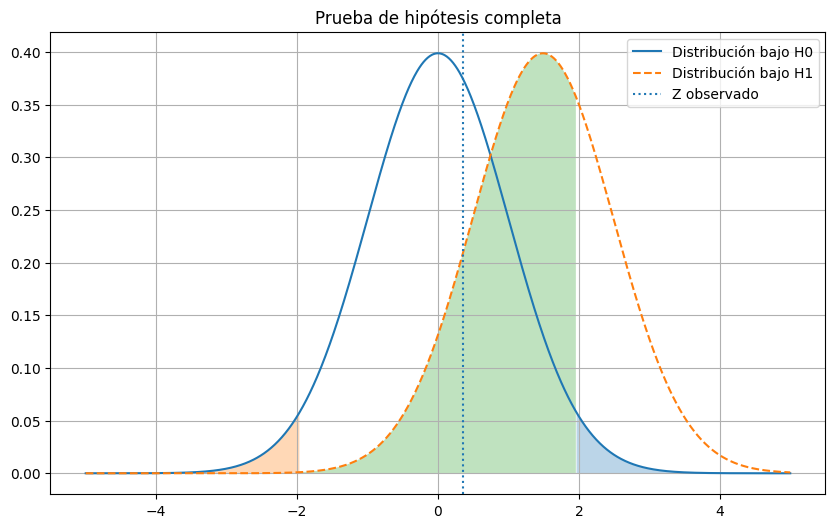

0.3577708763999693
False
0.7205147871362532
0.6802756473119772
(np.float64(87.85043237827026), np.float64(93.10956762172975))


In [ ]:
respuesta=prueba_hipotesis_completa(90.48,90,3,5,0.05,'dos',92)
print(f'{respuesta['z']}')
print(f'{respuesta["decision"]}')
print(f'{respuesta["p_value"]}')
print(f'{respuesta["beta"]}')
print(f'{respuesta["IC"]}')